In [4]:
import numpy as np
import math as mh
from sklearn.utils import shuffle
import matplotlib.pyplot as plt

### Реализация нейронного газа

In [2]:
def Neural_gas(X, norm_coeff = 10**5,
                epsilon1 = 0.2,
                epsilon2 = 0.005,
                max_age = 25,
                epochs=35,
                count_iter=80,
                err_alpha = 0.5,
                err_betta =0.954):

    # Объявление нейронов
    neirons={0:{"vector" : np.random.uniform(np.min(X, axis = 0), np.max(X, axis = 0)), "vertexes" : [[1,0]], "Lockal_error": 0},
             1:{"vector" : np.random.uniform(np.min(X, axis = 0), np.max(X, axis = 0)), "vertexes" : [[0,0]],"Lockal_error": 0}}
    
    X /= norm_coeff
    
    for i in (0,1):
        neirons[i]["vector"] = neirons[i]["vector"].astype("float32")
        neirons[i]["vector"] /= norm_coeff  
    
    for epoch in range(epochs):
    
        for i in range(len(X)):
    
            min_dist = 10**20
            number_great_neiron_1=0
            number_great_neiron_2=0

            # Поиск двух ближайших нейронов к текущему семплу
            for j in list(neirons.keys()):
                dist = np.sqrt(np.sum(np.square(X[i]-neirons[j]["vector"])))
    
                if dist<min_dist:
                    min_dist=dist
                    number_great_neiron_1=j
            
            min_dist = 10**20
            for j in list(neirons.keys()):
                dist = np.sqrt(np.sum(np.square(X[i]-neirons[j]["vector"])))
                if dist<min_dist and j!=number_great_neiron_1:
                    min_dist=dist
                    number_great_neiron_2=j

            # Обновление локальной ошибки, положения ближайшего нейрона и его соседей
            neirons[number_great_neiron_1]["Lockal_error"]+=np.sum(np.square(X[i]-neirons[number_great_neiron_1]["vector"]))
            neirons[number_great_neiron_1]["vector"]+=epsilon1*(X[i]-neirons[number_great_neiron_1]["vector"])
    
           
            for k in neirons[number_great_neiron_1]["vertexes"]:
                neirons[k[0]]["Lockal_error"]+=np.sum(np.square(X[i]-neirons[k[0]]["vector"]))
                neirons[k[0]]["vector"]+=epsilon2*(X[i]-neirons[k[0]]["vector"])
                k[1]+=1
    
                for l in neirons[k[0]]["vertexes"]:
                    if l[0]==number_great_neiron_1: # or (l[0] not in out_list):
                        l[1]+=1
                        break
                        
            # Обновление связей и возрастов
            flag1=True
            for  k in neirons[number_great_neiron_1]["vertexes"]:
                if number_great_neiron_2 == k[0]:
                    k[1]=0
                    flag1=False
                    break
    
            flag2=True
            for  k in neirons[number_great_neiron_2]["vertexes"]:
                if number_great_neiron_1 == k[0]:
                    k[1]=0
                    flag2=False
                    break
    
            if (flag1 and flag2):
                neirons[number_great_neiron_1]["vertexes"].append([number_great_neiron_2,0])
                neirons[number_great_neiron_2]["vertexes"].append([number_great_neiron_1,0])
            
            # Обновление связей с учётом их возрастов
            for j in neirons:
                new_ver=[]
                for k in neirons[j]["vertexes"]:
                    if k[1]<=max_age:
                       new_ver.append(k)
                neirons[j]["vertexes"]=new_ver
            
            new_neirons={}
            keys=list(neirons.keys())
            for j in keys:
                if len(neirons[j]["vertexes"]):
                    new_neirons[j]=neirons[j]
    
            neirons=new_neirons

            # Вставка нового нейрона
            if (epoch*len(X)+i+1) % count_iter == 0:
                max_err=-1
                neiron_err_1=0
                for j in (list(neirons.keys())):
                    if neirons[j]["Lockal_error"]>max_err:
                        max_err=neirons[j]["Lockal_error"]
                        neiron_err_1=j
    
                max_err=-1
                neiron_err_2=0
                for j in neirons[neiron_err_1]["vertexes"]:
                    if neirons[j[0]]["Lockal_error"]>max_err:
                        max_err=neirons[j[0]]["Lockal_error"]
                        neiron_err_2=j[0]
    
                new_neiron = max(list(neirons.keys()))+1
                neirons[new_neiron]={}
                neirons[new_neiron]["vector"]=(neirons[neiron_err_1]["vector"]+neirons[neiron_err_2]["vector"])/2
                neirons[new_neiron]["Lockal_error"]=neirons[neiron_err_1]["Lockal_error"]*err_betta
                neirons[new_neiron]["vertexes"]=[[neiron_err_1,0],[neiron_err_2,0]]
    
                neirons[neiron_err_1]["Lockal_error"]*=err_alpha
                neirons[neiron_err_2]["Lockal_error"]*=err_alpha
    
                for j in neirons[neiron_err_1]["vertexes"]:
                    if j[0]==neiron_err_2:
                        neirons[new_neiron]["vertexes"][0][1],neirons[new_neiron]["vertexes"][1][1]=j[1],j[1]
                        j[0]=new_neiron
                        break
    
                for j in neirons[neiron_err_2]["vertexes"]:
                    if j[0]==neiron_err_1:
                        j[0]=new_neiron
                        break
        
    
    # Разбиение по кластерам исходя из компонент связности полученного графа
    sp_sm={}
    labs = {}
    for i in list(neirons.keys()):
        sp_sm[i]=[k[0] for k in neirons[i]["vertexes"]]
        labs[i]=1
    
    components={}
    count_comp=0
    while 1 in labs.values():
        for i in list(labs.keys()):
            if labs[i]:
                memory=[i]
                break
    
        component=[]
        while len(memory)>0:
            if labs[memory[0]]:
                component.append(memory[0])
                for i in sp_sm[memory[0]]:
                    if labs[i]:
                        memory.append(i)
    
            labs[memory[0]]=0
            del memory[0] 
    
        components[count_comp]=list(component)
        count_comp+=1
    
    classes=[[] for i in range(len(components))]
    for x in X:
        min_dist=10**20
        class_number=0
        for i in components:
            for j in components[i]:
                dist = np.sqrt(np.sum(np.square(x-neirons[j]["vector"])))
                if dist<min_dist:
                    min_dist=dist
                    class_number=i
        classes[class_number].append(x*norm_coeff)
    
    return classes

### Тест 1 (простые фигуры, явная кластеризация)

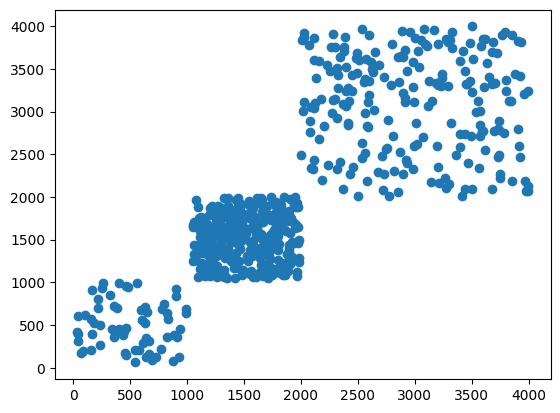

In [9]:
dim = 2

X1 = np.random.randint(10, 1000, (64, dim))
X3 = np.random.randint(1050, 2000, (300, dim))
X2 = np.random.randint(2000,4000, (220, dim))
X=np.array(list(X1)+list(X2)+list(X3))


X=shuffle(X)

df={"x":[i[0] for i in X],"y": [i[1] for i in X]}
plt.scatter(x = df["x"], y = df["y"], marker='o')
plt.show()
X=X.astype("float32")

In [10]:
classes = Neural_gas(X)

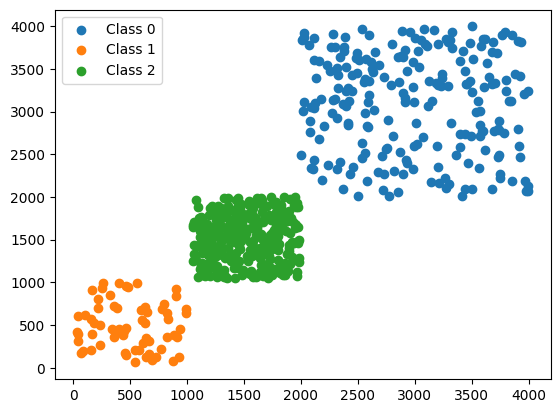

In [11]:
plt.figure()
for idx, class_points in enumerate(classes):
    x = [point[0] for point in class_points]
    y = [point[1] for point in class_points]
    plt.scatter(x, y, label=f'Class {idx}', marker='o')

plt.legend()
plt.show()

### Тест 2 (не явная кластеризация)

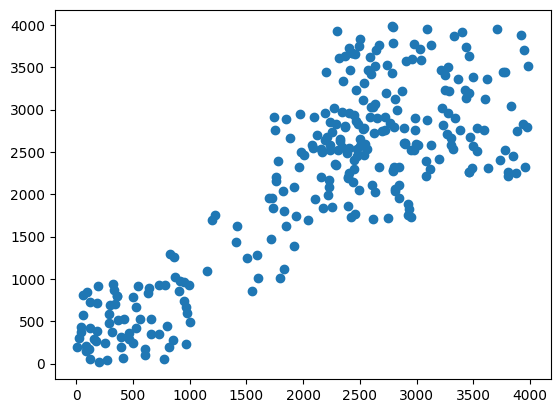

In [12]:
X1 = np.random.randint(10, 1000, (64, dim))
X3 = np.random.randint(800, 2000, (20, dim))
X4 = np.random.randint(1700, 3000, (85, dim))
X2 = np.random.randint(2200,4000, (120, dim))
X=np.array(list(X1)+list(X2)+list(X3)+list(X4))

X=shuffle(X)

df={"x":[i[0] for i in X],"y": [i[1] for i in X]}
plt.scatter(x = df["x"], y = df["y"], marker='o')
plt.show()
X=X.astype("float32")

In [13]:
classes = Neural_gas(X)

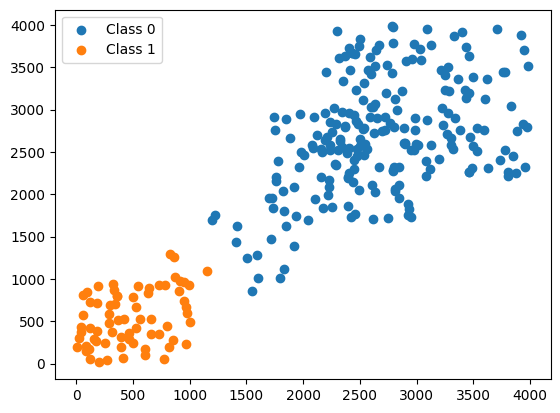

In [14]:
plt.figure()
for idx, class_points in enumerate(classes):
    x = [point[0] for point in class_points]
    y = [point[1] for point in class_points]
    plt.scatter(x, y, label=f'Class {idx}', marker='o')

plt.legend()
plt.show()

### Тест 3 (сложные фигуры, простая кластеризация):

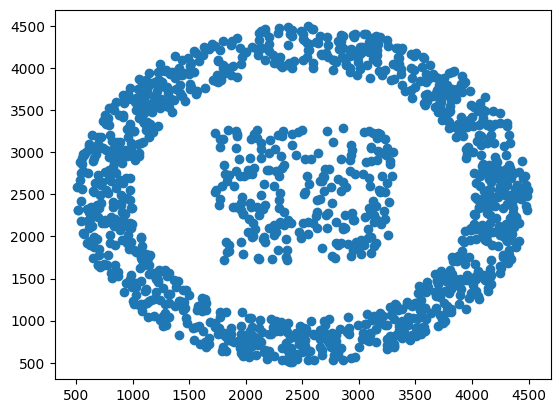

In [17]:
X1 = np.random.randint(1700,3300, (220, dim))
X22 = np.random.randint(0,5000, (5000, dim))
X2=[]
for x in X22:
    if ((x[0]-2500)**2+(x[1]-2500)**2)<=2000**2 and ((x[0]-2500)**2+(x[1]-2500)**2)>=1500**2:
        X2.append(x)
X=np.array(list(X1)+X2)

X=shuffle(X)

df={"x":[i[0] for i in X],"y": [i[1] for i in X]}
plt.scatter(x = df["x"], y = df["y"], marker='o')
plt.show()
X=X.astype("float32")

In [18]:
classes = Neural_gas(X)

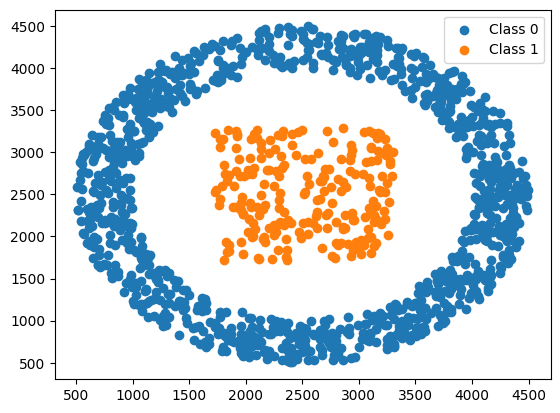

In [19]:
plt.figure()
for idx, class_points in enumerate(classes):
    x = [point[0] for point in class_points]
    y = [point[1] for point in class_points]
    plt.scatter(x, y, label=f'Class {idx}', marker='o')

plt.legend()
plt.show()

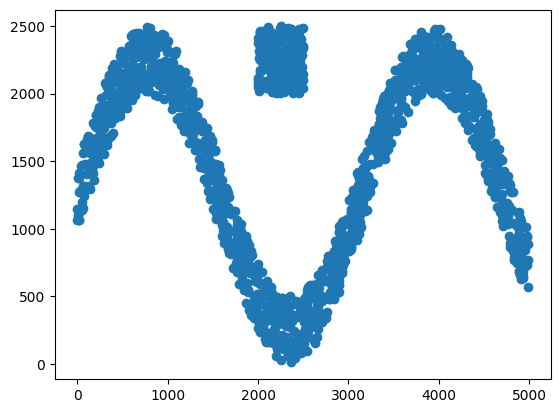

In [20]:
X1 = np.random.randint(2000,2500, (220, dim))
X22 = np.random.randint(0,5000, (15000, dim))
X2=[]
for x in X22:
    if x[1]>=mh.sin(x[0]/500)*1000+1000 and x[1]<=mh.sin(x[0]/500)*1000+1500:
        X2.append(x)
X=np.array(list(X1)+X2)


X=shuffle(X)

df={"x":[i[0] for i in X],"y": [i[1] for i in X]}
plt.scatter(x = df["x"], y = df["y"], marker='o')
plt.show()
X=X.astype("float32")

In [21]:
classes = Neural_gas(X)

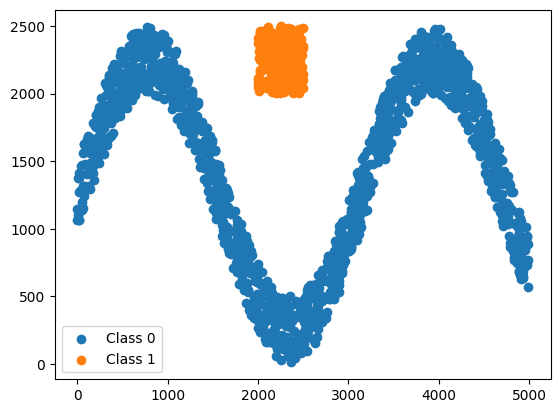

In [22]:
plt.figure()
for idx, class_points in enumerate(classes):
    x = [point[0] for point in class_points]
    y = [point[1] for point in class_points]
    plt.scatter(x, y, label=f'Class {idx}', marker='o')

plt.legend()
plt.show()